In [ ]:
# Libraries
import sf_quant as sf
import polars as pl
import datetime as dt
import os
import math
import io
import re
import zipfile
import requests
import pandas as pd
import numpy as np
import statsmodels.api as sm

# params
start = dt.date(2019, 1, 1)
end   = dt.date(2024, 12, 31)

base = "/home/nchasem/sf-quant-labs/research/data"

DAILY_RET_ABS_CAP_PCT = 200.0

QTR_RET_ABS_CAP_DEC = 5.0

USE_IN_UNIVERSE_FILTER = True

cols = [
    "date",
    "barrid",
    "ticker",
    "cusip",
    "market_cap",
    "return", 
    "in_universe",
    "russell_1000",
    "russell_2000",
]

# load assets
df = sf.data.load_assets(start=start, end=end, in_universe=False, columns=cols)

# standardize types + create cusip8
df = (
    df
    .with_columns([
        pl.col("date").cast(pl.Date),
        pl.col("barrid").cast(pl.Utf8, strict=False),
        pl.col("ticker").cast(pl.Utf8, strict=False),
        pl.col("cusip").cast(pl.Utf8, strict=False),
        pl.col("market_cap").cast(pl.Float64, strict=False),
        pl.col("return").cast(pl.Float64, strict=False),  # NOTE: percent units
    ])
    .with_columns(
        pl.when(pl.col("cusip").is_not_null())
          .then(pl.col("cusip").str.slice(0, 8))
          .otherwise(None)
          .alias("cusip8")
    )
)

print("Loaded daily assets:", df.shape)
print(df.head())

# read raw CapIQ IO data (percent owned + shares held), which are in wide format with multiple lagged columns
io_raw = pl.read_csv(f"{base}/IO_pct.csv", has_header=False)
sh_raw = pl.read_csv(f"{base}/inst_shares_held.csv", has_header=False)

header_row_idx = 2 # zero-based index of the header row in the raw CSV files

io_header = list(io_raw.row(header_row_idx))
sh_header = list(sh_raw.row(header_row_idx))

# Map old column names to new column names, skipping unnamed/empty columns
io_mapping = {}
for old, new in zip(io_raw.columns, io_header):
    if new is None:
        continue
    new_str = str(new).strip()
    if new_str == "" or new_str.lower().startswith("unnamed"):
        continue
    io_mapping[old] = new_str

sh_mapping = {}
for old, new in zip(sh_raw.columns, sh_header):
    if new is None:
        continue
    new_str = str(new).strip()
    if new_str == "" or new_str.lower().startswith("unnamed"):
        continue
    sh_mapping[old] = new_str

io_df = io_raw.slice(header_row_idx + 1).rename(io_mapping)
sh_df = sh_raw.slice(header_row_idx + 1).rename(sh_mapping)

print("\nIO columns:\n", io_df.columns)
print("\nShares columns:\n", sh_df.columns)

pct_cols = [c for c in io_df.columns if "Institutions - % Owned [Latest Quarter" in c]
shares_cols = [c for c in sh_df.columns if "Institutions - Number of Common Shares Held [Latest Quarter" in c]

io_long = (
    io_df
    .select(["CIK", "Ticker"] + pct_cols)
    .melt(id_vars=["CIK", "Ticker"], value_vars=pct_cols, variable_name="col", value_name="inst_pct_capiq_raw")
    .with_columns(
        pl.col("inst_pct_capiq_raw")
          .cast(pl.Utf8)
          .str.strip_chars()
          .str.replace("%", "")
          .str.replace(",", "")
          .str.replace("-", "")
          .cast(pl.Float64, strict=False)
          .alias("inst_pct_capiq")
    )
    .drop("inst_pct_capiq_raw")
    .with_columns(
        pl.col("col")
          .str.extract(r"Latest Quarter(-\d+)?", group_index=1)
          .fill_null("0")
          .cast(pl.Int32)
          .alias("q_lag")
    )
)

sh_long = (
    sh_df
    .select(["CIK", "Ticker"] + shares_cols)
    .melt(id_vars=["CIK", "Ticker"], value_vars=shares_cols, variable_name="col", value_name="inst_shares_held_raw")
    .with_columns(
        pl.col("inst_shares_held_raw")
          .cast(pl.Utf8)
          .str.strip_chars()
          .str.replace(",", "")
          .str.replace("-", "")
          .cast(pl.Float64, strict=False)
          .alias("inst_shares_held")
    )
    .drop("inst_shares_held_raw")
    .with_columns(
        pl.col("col")
          .str.extract(r"Latest Quarter(-\d+)?", group_index=1)
          .fill_null("0")
          .cast(pl.Int32)
          .alias("q_lag")
    )
)

io_panel = (
    io_long.drop("col")
    .join(sh_long.drop("col"), on=["CIK", "Ticker", "q_lag"], how="outer")
    .with_columns([
        pl.col("CIK").cast(pl.Utf8, strict=False),
        pl.col("Ticker").cast(pl.Utf8, strict=False),
    ])
    .filter(pl.col("CIK").is_not_null() & (pl.col("CIK") != "-"))
    .with_columns(
        pl.col("CIK").cast(pl.Utf8).str.strip_chars().str.zfill(10).alias("cik")
    )
    .drop("CIK")
)

# Drop duplicate RHS key cols if they exist
for c in ["CIK_right", "Ticker_right", "q_lag_right"]:
    if c in io_panel.columns:
        io_panel = io_panel.drop(c)

io_panel = io_panel.sort(["cik", "q_lag"])
io_panel.write_parquet(f"{base}/io_panel_capiq.parquet")
print("\nSaved IO panel:", f"{base}/io_panel_capiq.parquet", "shape:", io_panel.shape)

# ----------------------------
# map sf_quant daily -> gvkey using link.csv (CUSIP time-varying)
# ----------------------------
link = pl.read_csv(f"{base}/link.csv")

link = (
    link
    .with_columns([
        pl.col("cusip").cast(pl.Utf8, strict=False).str.slice(0, 8).alias("cusip8"),
        pl.col("LINKDT").str.strptime(pl.Date, strict=False).alias("link_start"),
        pl.col("LINKENDDT").str.strptime(pl.Date, strict=False).alias("link_end"),
    ])
    .with_columns(
        pl.when(pl.col("link_end").is_null())
          .then(dt.date(2099, 12, 31))
          .otherwise(pl.col("link_end"))
          .alias("link_end")
    )
)

link_small = (
    link
    .select(["cusip8", "GVKEY", "link_start", "link_end"])
    .with_columns(pl.col("GVKEY").alias("gvkey"))
    .drop("GVKEY")
)

df_gv = (
    df
    .join(link_small, on="cusip8", how="left")
    .filter(
        pl.col("gvkey").is_not_null() &
        (pl.col("date") >= pl.col("link_start")) &
        (pl.col("date") <= pl.col("link_end"))
    )
)

print("\nDaily rows with gvkey:", df_gv.shape)
print(df_gv.select(["date", "cusip8", "gvkey"]).head())

# ----------------------------
# build CANONICAL quarterly CRSP panel
#   - filter bad rows + convert return units
#   - collapse to gvkey-date (VW across securities/share classes)
#   - compound daily gvkey returns into quarterly returns
# ----------------------------

# remove absurd daily glitches, require valid mcap
df_gv = df_gv.filter(
    pl.col("return").is_not_null()
    & (pl.col("return").abs() < DAILY_RET_ABS_CAP_PCT)
    & pl.col("market_cap").is_not_null()
    & (pl.col("market_cap") > 0)
)

# daily percent -> daily decimal ONCE
df_gv = df_gv.with_columns((pl.col("return") / 100.0).alias("ret_d"))

# guard: cannot take log(1+r) if r <= -1
df_gv = df_gv.filter(pl.col("ret_d") > -0.999)

# collapse to one row per gvkey-date (VW across securities)
gv_d = (
    df_gv
    .group_by(["gvkey", "date"])
    .agg([
        pl.col("market_cap").sum().alias("mcap_gv"),

        (pl.col("market_cap") * pl.col("ret_d")).sum().alias("num"),
        pl.col("market_cap").sum().alias("den"),

        pl.col("cusip8").last().alias("cusip8"),
        pl.col("cusip").last().alias("cusip"),
        pl.col("ticker").last().alias("ticker"),
        pl.col("barrid").last().alias("barrid"),

        pl.col("in_universe").any().alias("in_universe"),
        pl.col("russell_1000").any().alias("russell_1000"),
        pl.col("russell_2000").any().alias("russell_2000"),
    ])
    .with_columns((pl.col("num") / pl.col("den")).alias("ret_gv_d"))
    .drop(["num", "den"])
    .filter(pl.col("ret_gv_d").is_not_null())
)

print("\nSanity gvkey daily return distribution:")
print(gv_d.select([
    pl.col("ret_gv_d").abs().quantile(0.95).alias("p95_abs"),
    pl.col("ret_gv_d").abs().quantile(0.99).alias("p99_abs"),
    pl.col("ret_gv_d").abs().max().alias("max_abs"),
]))

# add year/quarter + canonical calendar qdate
gv_d = gv_d.with_columns([
    pl.col("date").dt.year().alias("year"),
    pl.col("date").dt.quarter().alias("quarter"),
]).with_columns(
    pl.when(pl.col("quarter") == 1).then(pl.date(pl.col("year"), 3, 31))
    .when(pl.col("quarter") == 2).then(pl.date(pl.col("year"), 6, 30))
    .when(pl.col("quarter") == 3).then(pl.date(pl.col("year"), 9, 30))
    .otherwise(pl.date(pl.col("year"), 12, 31))
    .alias("qdate")
)

# compound within quarter: exp(sum(log(1+r))) - 1
crsp_q = (
    gv_d
    .sort(["gvkey", "date"])
    .group_by(["gvkey", "year", "quarter", "qdate"])
    .agg([
        pl.col("date").max().alias("last_obs_date"),

        pl.col("cusip8").last().alias("cusip8"),
        pl.col("cusip").last().alias("cusip"),
        pl.col("ticker").last().alias("ticker"),
        pl.col("barrid").last().alias("barrid"),

        pl.col("in_universe").any().alias("in_universe"),
        pl.col("russell_1000").any().alias("russell_1000"),
        pl.col("russell_2000").any().alias("russell_2000"),

        pl.col("mcap_gv").last().alias("market_cap"),

        (pl.col("ret_gv_d") + 1.0).log().sum().exp().sub(1.0).alias("ret_q"),
    ])
    .filter(pl.col("ret_q").is_not_null())
    .filter(pl.col("ret_q").abs() <= QTR_RET_ABS_CAP_DEC)
    .sort(["gvkey", "qdate"])
)

print("\nqdate months (should be 3/6/9/12):")
print(crsp_q.select(pl.col("qdate").dt.month().unique().alias("m")).sort("m"))
print("crsp_q shape:", crsp_q.shape)
print(crsp_q.select(["gvkey", "qdate", "ret_q", "market_cap"]).head())

# ----------------------------
# anchor CapIQ lags -> calendar quarter ends (qdate)
# ----------------------------
LATEST_QDATE = crsp_q.select(pl.col("qdate").max()).item()
print("\nAnchoring CapIQ q_lag=0 to calendar qdate:", LATEST_QDATE)

def subtract_quarters(date: dt.date, k: int) -> dt.date:
    y = date.year
    q = (date.month - 1) // 3 + 1
    q_new = q - k
    y_new = y + (q_new - 1) // 4
    q_new = (q_new - 1) % 4 + 1
    m = {1: 3, 2: 6, 3: 9, 4: 12}[q_new]
    d = {3: 31, 6: 30, 9: 30, 12: 31}[m]
    return dt.date(y_new, m, d)

q_map = (
    io_panel
    .select("q_lag")
    .unique()
    .with_columns(
        pl.col("q_lag")
          .map_elements(lambda x: subtract_quarters(LATEST_QDATE, -int(x)))
          .alias("qdate")
    )
)

io_panel_q = (
    io_panel
    .join(q_map, on="q_lag", how="left")
    .with_columns([
        pl.col("qdate").dt.year().alias("year"),
        pl.col("qdate").dt.quarter().alias("quarter"),
    ])
)

# Collapse duplicates: one row per (cik, qdate)
io_panel_q = (
    io_panel_q
    .group_by(["cik", "qdate"])
    .agg([
        pl.col("inst_pct_capiq").mean().alias("inst_pct_capiq"),     # percent points
        pl.col("inst_shares_held").mean().alias("inst_shares_held"),
        pl.first("Ticker").alias("Ticker"),
        pl.first("year").alias("year"),
        pl.first("quarter").alias("quarter"),
    ])
    .sort(["cik", "qdate"])
)

# Create decimal version
io_panel_q = io_panel_q.with_columns((pl.col("inst_pct_capiq") / 100.0).alias("inst_pct_capiq_d"))

io_panel_q.write_parquet(os.path.join(base, "io_panel_capiq_quarterly.parquet"))
print("\nSaved:", os.path.join(base, "io_panel_capiq_quarterly.parquet"), "shape:", io_panel_q.shape)

# ----------------------------
# bridge cik -> gvkey using merge_table.csv
# ----------------------------
merge_path = os.path.join(base, "merge_table.csv")
bridge_raw = pl.read_csv(merge_path, infer_schema_length=10000)

colmap = {}
for c in bridge_raw.columns:
    lc = c.lower()
    if lc == "gvkey":
        colmap[c] = "gvkey"
    if lc == "cik":
        colmap[c] = "cik"

bridge_tmp = bridge_raw.rename(colmap)

bridge = (
    bridge_tmp
    .select([c for c in ["gvkey", "cik"] if c in bridge_tmp.columns])
    .with_columns([
        pl.col("gvkey").cast(pl.Int64, strict=False),
        pl.col("cik").cast(pl.Utf8, strict=False).str.strip_chars().str.zfill(10),
    ])
    .filter(pl.col("gvkey").is_not_null() & pl.col("cik").is_not_null() & (pl.col("cik") != ""))
    .unique(subset=["gvkey", "cik"])
)

print("\nBridge rows:", bridge.height)
print(bridge.head())

io_panel_q_gv = (
    io_panel_q
    .with_columns(pl.col("cik").cast(pl.Utf8).str.strip_chars().str.zfill(10))
    .join(bridge, on="cik", how="left")
)

print("IO rows with gvkey:", io_panel_q_gv.filter(pl.col("gvkey").is_not_null()).height, "of", io_panel_q_gv.height)

# ----------------------------
# merge IO onto CRSP quarterly panel using (gvkey, qdate)
# ----------------------------
final_panel = (
    crsp_q
    .join(
        io_panel_q_gv.select(["gvkey", "qdate", "inst_pct_capiq", "inst_pct_capiq_d", "inst_shares_held"]),
        on=["gvkey", "qdate"],
        how="left"
    )
    .sort(["gvkey", "qdate"])
)

print("\nFinal merged shape:", final_panel.shape)
print(
    final_panel
    .group_by("qdate")
    .agg([
        pl.col("inst_pct_capiq").is_not_null().mean().alias("io_coverage_rate"),
        pl.len().alias("n_firms"),
    ])
    .sort("qdate")
    .tail(12)
)

# ----------------------------
# forward return + deciles + EW/VW + HML
# ----------------------------
final_panel = (
    final_panel
    .with_columns(pl.col("ret_q").shift(-1).over("gvkey").alias("ret_fwd"))
    .filter(pl.col("ret_fwd").is_not_null())
)

# Portfolio formation sample
panel = final_panel.filter(pl.col("inst_pct_capiq_d").is_not_null())
if USE_IN_UNIVERSE_FILTER:
    panel = panel.filter(pl.col("in_universe") == True)

# Rank-deciles
panel = (
    panel
    .with_columns(pl.col("inst_pct_capiq_d").rank("dense").over("qdate").alias("io_rank"))
    .with_columns(
        (
            (pl.col("io_rank") / pl.col("io_rank").max().over("qdate") * 10)
            .ceil()
            .cast(pl.Int32)
        ).alias("io_decile")
    )
    .drop("io_rank")
)

# EW decile returns
dec_ew = (
    panel
    .group_by(["qdate", "io_decile"])
    .agg(pl.col("ret_fwd").mean().alias("ew_ret"))
    .sort(["qdate", "io_decile"])
)

# VW decile returns (weights = formation market_cap)
dec_vw = (
    panel
    .filter(pl.col("market_cap").is_not_null() & (pl.col("market_cap") > 0))
    .with_columns(
        (pl.col("market_cap") / pl.col("market_cap").sum().over(["qdate", "io_decile"])).alias("w")
    )
    .group_by(["qdate", "io_decile"])
    .agg((pl.col("w") * pl.col("ret_fwd")).sum().alias("vw_ret"))
    .sort(["qdate", "io_decile"])
)

# spread
hml_ew = (
    dec_ew
    .filter(pl.col("io_decile").is_in([1, 10]))
    .pivot(values="ew_ret", index="qdate", columns="io_decile")
    .with_columns((pl.col("10") - pl.col("1")).alias("HML_EW"))
    .select(["qdate", "HML_EW"])
    .sort("qdate")
)

hml_vw = (
    dec_vw
    .filter(pl.col("io_decile").is_in([1, 10]))
    .pivot(values="vw_ret", index="qdate", columns="io_decile")
    .with_columns((pl.col("10") - pl.col("1")).alias("HML_VW"))
    .select(["qdate", "HML_VW"])
    .sort("qdate")
)

def summarize(series: pl.DataFrame, col: str):
    n = series.select(pl.len()).item()
    mean = series.select(pl.col(col).mean()).item()
    sd = series.select(pl.col(col).std()).item()
    t = (mean / (sd / math.sqrt(n))) if (sd is not None and sd > 0 and n > 1) else None
    ann_mean = mean * 4
    print(f"\n{col}: n={n}")
    print(f"  mean (qtr)   = {mean:.6f}")
    print(f"  sd   (qtr)   = {sd:.6f}")
    print(f"  t-stat (qtr) = {t:.3f}" if t is not None else "  t-stat (qtr) = NA")
    print(f"  mean (ann)   = {ann_mean:.6f}")

print("\nEW decile returns sample:")
print(dec_ew.head(20))

print("\nVW decile returns sample:")
print(dec_vw.head(20))

print("\nLast 8 EW HML:")
print(hml_ew.tail(8))

print("\nLast 8 VW HML:")
print(hml_vw.tail(8))

summarize(hml_ew, "HML_EW")
summarize(hml_vw, "HML_VW")

# Save final panel
out_path = os.path.join(base, "final_panel_io_quarterly.parquet")
final_panel.write_parquet(out_path)
print("\nSaved final merged panel to:", out_path)
print("final_panel columns:", final_panel.columns)

/home/nchasem/sf-quant-labs/.venv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-02 12:48:06,022	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Loaded daily assets: (31015232, 10)
shape: (5, 10)
┌────────────┬─────────┬────────┬───────────┬───┬─────────────┬────────────┬────────────┬──────────┐
│ date       ┆ barrid  ┆ ticker ┆ cusip     ┆ … ┆ in_universe ┆ russell_10 ┆ russell_20 ┆ cusip8   │
│ ---        ┆ ---     ┆ ---    ┆ ---       ┆   ┆ ---         ┆ 00         ┆ 00         ┆ ---      │
│ date       ┆ str     ┆ str    ┆ str       ┆   ┆ bool        ┆ ---        ┆ ---        ┆ str      │
│            ┆         ┆        ┆           ┆   ┆             ┆ bool       ┆ bool       ┆          │
╞════════════╪═════════╪════════╪═══════════╪═══╪═════════════╪════════════╪════════════╪══════════╡
│ 2022-12-29 ┆ ARGA1B1 ┆ null   ┆ P0R67N384 ┆ … ┆ null        ┆ null       ┆ null       ┆ P0R67N38 │
│ 2022-12-30 ┆ ARGA1B1 ┆ null   ┆ P0R67N384 ┆ … ┆ null        ┆ null       ┆ null       ┆ P0R67N38 │
│ 2023-01-03 ┆ ARGA1B1 ┆ null   ┆ P0R67N384 ┆ … ┆ null        ┆ null       ┆ null       ┆ P0R67N38 │
│ 2023-01-04 ┆ ARGA1B1 ┆ null   ┆ P0R67N

/tmp/ipykernel_3551457/3102944366.py:119: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(id_vars=["CIK", "Ticker"], value_vars=pct_cols, variable_name="col", value_name="inst_pct_capiq_raw")
/tmp/ipykernel_3551457/3102944366.py:143: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(id_vars=["CIK", "Ticker"], value_vars=shares_cols, variable_name="col", value_name="inst_shares_held_raw")
/tmp/ipykernel_3551457/3102944366.py:165: DeprecationWarning: use of `how='outer'` should be replaced with `how='full'`.
(Deprecated in version 0.20.29)
  .join(sh_long.drop("col"), on=["CIK", "Ticker", "q_lag"], how="outer")



Saved IO panel: /home/nchasem/sf-quant-labs/research/data/io_panel_capiq.parquet shape: (153672, 5)

Daily rows with gvkey: (14013809, 13)
shape: (5, 3)
┌────────────┬──────────┬───────┐
│ date       ┆ cusip8   ┆ gvkey │
│ ---        ┆ ---      ┆ ---   │
│ date       ┆ str      ┆ i64   │
╞════════════╪══════════╪═══════╡
│ 2022-06-23 ┆ 28551210 ┆ 16721 │
│ 2022-06-24 ┆ 28551210 ┆ 16721 │
│ 2022-06-27 ┆ 28551210 ┆ 16721 │
│ 2022-06-28 ┆ 28551210 ┆ 16721 │
│ 2022-06-29 ┆ 28551210 ┆ 16721 │
└────────────┴──────────┴───────┘

Sanity gvkey daily return distribution:
shape: (1, 3)
┌──────────┬──────────┬─────────┐
│ p95_abs  ┆ p99_abs  ┆ max_abs │
│ ---      ┆ ---      ┆ ---     │
│ f64      ┆ f64      ┆ f64     │
╞══════════╪══════════╪═════════╡
│ 0.070936 ┆ 0.161023 ┆ 1.9975  │
└──────────┴──────────┴─────────┘

qdate months (should be 3/6/9/12):
shape: (4, 1)
┌─────┐
│ m   │
│ --- │
│ i8  │
╞═════╡
│ 3   │
│ 6   │
│ 9   │
│ 12  │
└─────┘
crsp_q shape: (109755, 14)
shape: (5, 4)
┌───────

/tmp/ipykernel_3551457/3102944366.py:341: MapWithoutReturnDtypeWarning: 'return_dtype' of function python_udf must be set

A later expression might fail because the output type is not known. Set return_dtype=pl.self_dtype() if the type is unchanged, or set the proper output data type.
  .with_columns(



Final merged shape: (109755, 17)
shape: (12, 3)
┌────────────┬──────────────────┬─────────┐
│ qdate      ┆ io_coverage_rate ┆ n_firms │
│ ---        ┆ ---              ┆ ---     │
│ date       ┆ f64              ┆ u32     │
╞════════════╪══════════════════╪═════════╡
│ 2022-03-31 ┆ 0.530827         ┆ 4655    │
│ 2022-06-30 ┆ 0.534247         ┆ 4672    │
│ 2022-09-30 ┆ 0.534395         ┆ 4710    │
│ 2022-12-31 ┆ 0.538623         ┆ 4751    │
│ 2023-03-31 ┆ 0.54232          ┆ 4785    │
│ …          ┆ …                ┆ …       │
│ 2023-12-31 ┆ 0.550252         ┆ 4965    │
│ 2024-03-31 ┆ 0.553628         ┆ 5016    │
│ 2024-06-30 ┆ 0.556493         ┆ 5098    │
│ 2024-09-30 ┆ 0.559776         ┆ 5186    │
│ 2024-12-31 ┆ 0.562855         ┆ 5282    │
└────────────┴──────────────────┴─────────┘

EW decile returns sample:
shape: (20, 3)
┌────────────┬───────────┬──────────┐
│ qdate      ┆ io_decile ┆ ew_ret   │
│ ---        ┆ ---       ┆ ---      │
│ date       ┆ i32       ┆ f64      │
╞════════

/tmp/ipykernel_3551457/3102944366.py:493: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(values="ew_ret", index="qdate", columns="io_decile")
/tmp/ipykernel_3551457/3102944366.py:502: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(values="vw_ret", index="qdate", columns="io_decile")


In [ ]:
pl.Config.set_tbl_rows(50)
pl.Config.set_tbl_cols(20)

# ---- Decile table ----
decile_table = (
    dec_ew
    .drop_nulls(["ew_ret", "io_decile"])
    .group_by("io_decile")
    .agg([
        pl.col("ew_ret").mean().alias("mean_q"),
        pl.col("ew_ret").std().alias("sd_q"),
    ])
    .with_columns([
        (pl.col("mean_q") * 4).alias("mean_ann"),
        pl.when(pl.col("sd_q") > 0)
          .then((pl.col("mean_q") / pl.col("sd_q")) * math.sqrt(4))
          .otherwise(None)
          .alias("sharpe_ann"),
    ])
    .select([
        pl.col("io_decile").alias("Decile"),
        "mean_ann",
        "sharpe_ann",
    ])
    .sort("Decile")
)

# ---- Spread row ----
spread_row = (
    hml_ew
    .drop_nulls(["HML_EW"])
    .select([
        (pl.col("HML_EW").mean() * 4).alias("mean_ann"),
        pl.when(pl.col("HML_EW").std() > 0)
          .then((pl.col("HML_EW").mean() / pl.col("HML_EW").std()) * math.sqrt(4))
          .otherwise(None)
          .alias("sharpe_ann"),
    ])
    .with_columns(pl.lit(11).alias("Decile"))
    .select(["Decile", "mean_ann", "sharpe_ann"])
)

# ---- Combine ----
final_table = (
    pl.concat([decile_table, spread_row], how="vertical")
    .sort("Decile")
    .with_columns(
        pl.when(pl.col("Decile") == 11)
          .then(pl.lit("Spread"))
          .otherwise(pl.col("Decile").cast(pl.Utf8))
          .alias("Decile")
    )
)

print(final_table)

shape: (11, 3)
┌────────┬──────────┬────────────┐
│ Decile ┆ mean_ann ┆ sharpe_ann │
│ ---    ┆ ---      ┆ ---        │
│ str    ┆ f64      ┆ f64        │
╞════════╪══════════╪════════════╡
│ 1      ┆ 0.027774 ┆ 0.127166   │
│ 2      ┆ 0.192341 ┆ 0.842274   │
│ 3      ┆ 0.187794 ┆ 0.949791   │
│ 4      ┆ 0.226709 ┆ 1.148606   │
│ 5      ┆ 0.241184 ┆ 1.359398   │
│ 6      ┆ 0.202343 ┆ 1.181438   │
│ 7      ┆ 0.258142 ┆ 1.643019   │
│ 8      ┆ 0.249518 ┆ 1.59395    │
│ 9      ┆ 0.230117 ┆ 1.54954    │
│ 10     ┆ 0.211355 ┆ 1.248796   │
│ Spread ┆ 0.183581 ┆ 1.580847   │
└────────┴──────────┴────────────┘


In [ ]:
pl.Config.set_tbl_rows(50)
pl.Config.set_tbl_cols(20)

# ---- VW Decile table ----
decile_table_vw = (
    dec_vw
    .group_by("io_decile")
    .agg([
        pl.col("vw_ret").mean().alias("mean_q"),
        pl.col("vw_ret").std().alias("sd_q"),
    ])
    .with_columns([
        (pl.col("mean_q") * 4).alias("mean_ann"),
        (pl.col("mean_q") / pl.col("sd_q") * math.sqrt(4)).alias("sharpe_ann"),
    ])
    .select([
        pl.col("io_decile").alias("Decile"),
        "mean_ann",
        "sharpe_ann",
    ])
    .sort("Decile")
)

# ---- Spread (VW 10 - 1) ----
spread_row_vw = (
    hml_vw
    .select([
        (pl.col("HML_VW").mean() * 4).alias("mean_ann"),
        ((pl.col("HML_VW").mean() / pl.col("HML_VW").std()) * math.sqrt(4)).alias("sharpe_ann"),
    ])
    .with_columns(pl.lit(11).alias("Decile"))
    .select(["Decile", "mean_ann", "sharpe_ann"])
)

# ---- Combine ----
final_table_vw = (
    pl.concat([decile_table_vw, spread_row_vw], how="vertical")
    .sort("Decile")
    .with_columns(
        pl.when(pl.col("Decile") == 11)
          .then(pl.lit("Spread"))
          .otherwise(pl.col("Decile").cast(pl.Utf8))
          .alias("Decile")
    )
)

print(final_table_vw)

shape: (11, 3)
┌────────┬───────────┬────────────┐
│ Decile ┆ mean_ann  ┆ sharpe_ann │
│ ---    ┆ ---       ┆ ---        │
│ str    ┆ f64       ┆ f64        │
╞════════╪═══════════╪════════════╡
│ 1      ┆ -0.011229 ┆ -0.0965    │
│ 2      ┆ 0.599868  ┆ 1.020382   │
│ 3      ┆ 0.283348  ┆ 0.8401     │
│ 4      ┆ 0.188627  ┆ 0.811177   │
│ 5      ┆ 0.327728  ┆ 1.488544   │
│ 6      ┆ 0.272804  ┆ 1.178899   │
│ 7      ┆ 0.134391  ┆ 1.253994   │
│ 8      ┆ 0.134419  ┆ 1.328399   │
│ 9      ┆ 0.126349  ┆ 1.127596   │
│ 10     ┆ 0.052298  ┆ 0.449898   │
│ Spread ┆ 0.063528  ┆ 0.507421   │
└────────┴───────────┴────────────┘


In [ ]:
# Quintiles
panel_q5 = (
    panel
    .with_columns(
        pl.col("inst_pct_capiq_d")
          .rank("dense")
          .over("qdate")
          .alias("io_rank")
    )
    .with_columns(
        (
            (pl.col("io_rank") /
             pl.col("io_rank").max().over("qdate") * 5)
            .ceil()
            .cast(pl.Int32)
        ).alias("io_quintile")
    )
    .drop("io_rank")
)

# Equal-weight quintile returns
q5_ew = (
    panel_q5
    .group_by(["qdate", "io_quintile"])
    .agg(pl.col("ret_fwd").mean().alias("ew_ret"))
    .sort(["qdate", "io_quintile"])
)

# Spread Q5
hml_q5_ew = (
    q5_ew
    .filter(pl.col("io_quintile").is_in([1, 5]))
    .pivot(values="ew_ret", index="qdate", columns="io_quintile")
    .with_columns((pl.col("5") - pl.col("1")).alias("Spread_EW"))
    .select(["qdate", "Spread_EW"])
    .sort("qdate")
)

q5_vw = (
    panel_q5
    .filter(pl.col("market_cap").is_not_null() & (pl.col("market_cap") > 0))
    .with_columns(
        (pl.col("market_cap") /
         pl.col("market_cap").sum().over(["qdate", "io_quintile"]))
        .alias("w")
    )
    .group_by(["qdate", "io_quintile"])
    .agg((pl.col("w") * pl.col("ret_fwd")).sum().alias("vw_ret"))
    .sort(["qdate", "io_quintile"])
)

hml_q5_vw = (
    q5_vw
    .filter(pl.col("io_quintile").is_in([1, 5]))
    .pivot(values="vw_ret", index="qdate", columns="io_quintile")
    .with_columns((pl.col("5") - pl.col("1")).alias("Spread_VW"))
    .select(["qdate", "Spread_VW"])
    .sort("qdate")
)

q5_table_ew = (
    q5_ew
    .group_by("io_quintile")
    .agg([
        pl.col("ew_ret").mean().alias("mean_q"),
        pl.col("ew_ret").std().alias("sd_q"),
    ])
    .with_columns([
        (pl.col("mean_q") * 4).alias("mean_ann"),
        (pl.col("mean_q") / pl.col("sd_q") * math.sqrt(4)).alias("sharpe_ann"),
    ])
    .select([
        pl.col("io_quintile").alias("Quintile"),
        "mean_ann",
        "sharpe_ann",
    ])
    .sort("Quintile")
)

spread_row_q5_ew = (
    hml_q5_ew
    .select([
        (pl.col("Spread_EW").mean() * 4).alias("mean_ann"),
        ((pl.col("Spread_EW").mean() /
          pl.col("Spread_EW").std()) * math.sqrt(4)).alias("sharpe_ann"),
    ])
    .with_columns(pl.lit(6).alias("Quintile"))
    .select(["Quintile", "mean_ann", "sharpe_ann"])
)

final_q5_ew = (
    pl.concat([q5_table_ew, spread_row_q5_ew], how="vertical")
    .sort("Quintile")
    .with_columns(
        pl.when(pl.col("Quintile") == 6)
          .then(pl.lit("Spread"))
          .otherwise(pl.col("Quintile").cast(pl.Utf8))
          .alias("Quintile")
    )
)

print(final_q5_ew)

q5_table_vw = (
    q5_vw
    .group_by("io_quintile")
    .agg([
        pl.col("vw_ret").mean().alias("mean_q"),
        pl.col("vw_ret").std().alias("sd_q"),
    ])
    .with_columns([
        (pl.col("mean_q") * 4).alias("mean_ann"),
        (pl.col("mean_q") / pl.col("sd_q") * math.sqrt(4)).alias("sharpe_ann"),
    ])
    .select([
        pl.col("io_quintile").alias("Quintile"),
        "mean_ann",
        "sharpe_ann",
    ])
    .sort("Quintile")
)

spread_row_q5_vw = (
    hml_q5_vw
    .select([
        (pl.col("Spread_VW").mean() * 4).alias("mean_ann"),
        ((pl.col("Spread_VW").mean() /
          pl.col("Spread_VW").std()) * math.sqrt(4)).alias("sharpe_ann"),
    ])
    .with_columns(pl.lit(6).alias("Quintile"))
    .select(["Quintile", "mean_ann", "sharpe_ann"])
)

final_q5_vw = (
    pl.concat([q5_table_vw, spread_row_q5_vw], how="vertical")
    .sort("Quintile")
    .with_columns(
        pl.when(pl.col("Quintile") == 6)
          .then(pl.lit("Spread"))
          .otherwise(pl.col("Quintile").cast(pl.Utf8))
          .alias("Quintile")
    )
)

print(final_q5_vw)

shape: (6, 3)
┌──────────┬──────────┬────────────┐
│ Quintile ┆ mean_ann ┆ sharpe_ann │
│ ---      ┆ ---      ┆ ---        │
│ str      ┆ f64      ┆ f64        │
╞══════════╪══════════╪════════════╡
│ 1        ┆ 0.111815 ┆ 0.506384   │
│ 2        ┆ 0.207564 ┆ 1.059817   │
│ 3        ┆ 0.221836 ┆ 1.285287   │
│ 4        ┆ 0.25383  ┆ 1.624155   │
│ 5        ┆ 0.221354 ┆ 1.411999   │
│ Spread   ┆ 0.109539 ┆ 1.04206    │
└──────────┴──────────┴────────────┘
shape: (6, 3)
┌──────────┬───────────┬────────────┐
│ Quintile ┆ mean_ann  ┆ sharpe_ann │
│ ---      ┆ ---       ┆ ---        │
│ str      ┆ f64       ┆ f64        │
╞══════════╪═══════════╪════════════╡
│ 1        ┆ 0.552285  ┆ 1.02745    │
│ 2        ┆ 0.245313  ┆ 0.984267   │
│ 3        ┆ 0.341395  ┆ 1.913012   │
│ 4        ┆ 0.133125  ┆ 1.305054   │
│ 5        ┆ 0.104681  ┆ 0.96482    │
│ Spread   ┆ -0.447605 ┆ -0.872267  │
└──────────┴───────────┴────────────┘


/tmp/ipykernel_3551457/1221410795.py:34: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(values="ew_ret", index="qdate", columns="io_quintile")
/tmp/ipykernel_3551457/1221410795.py:56: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(values="vw_ret", index="qdate", columns="io_quintile")


/tmp/ipykernel_3551457/3377839524.py:6: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(values="ew_ret", index="qdate", columns="io_decile")


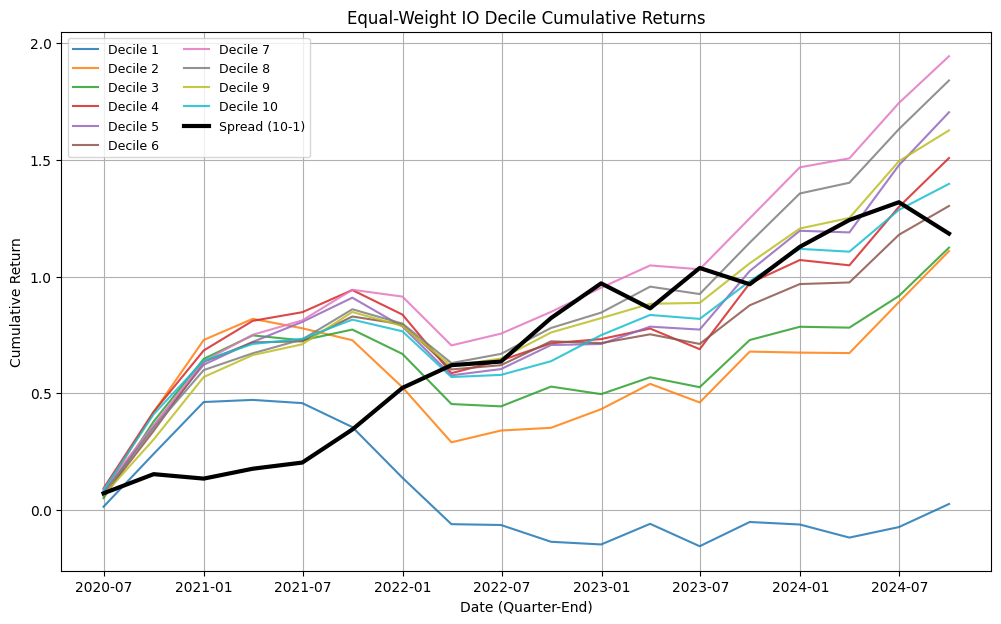

In [ ]:
# ---- Pivot to wide ----
dec_ew_wide = (
    dec_ew
    .pivot(values="ew_ret", index="qdate", columns="io_decile")
    .sort("qdate")
)

df_plot = dec_ew_wide.to_pandas().set_index("qdate")
df_plot.columns = df_plot.columns.map(str)

# ---- Cumulative RETURN ----
cum_ret = (1 + df_plot).cumprod() - 1

# Spread (10-1)
spread = df_plot["10"] - df_plot["1"]
cum_spread = (1 + spread).cumprod() - 1

# ---- Plot ----
plt.figure(figsize=(12,7))

for col in cum_ret.columns:
    plt.plot(cum_ret.index, cum_ret[col], label=f"Decile {col}", alpha=0.85)

plt.plot(cum_spread.index, cum_spread, linewidth=3, color="black", label="Spread (10-1)")

plt.title("Equal-Weight IO Decile Cumulative Returns")
plt.xlabel("Date (Quarter-End)")
plt.ylabel("Cumulative Return")

# Legend with all series
plt.legend(ncol=2, fontsize=9)
plt.grid(True)
plt.show()

In [ ]:
FF5_MONTHLY_URL = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip"

def load_ff5_monthly() -> pd.DataFrame:
    """
    Downloads Ken French FF5 (2x3) MONTHLY factors + RF.
    Returns DataFrame indexed by month-end with DECIMAL units:
    ['Mkt-RF','SMB','HML','RMW','CMA','RF'].
    Robust parsing: finds first YYYYMM data row; header assumed directly above it.
    """
    r = requests.get(FF5_MONTHLY_URL, timeout=60)
    r.raise_for_status()

    z = zipfile.ZipFile(io.BytesIO(r.content))
    csv_name = [n for n in z.namelist() if n.lower().endswith(".csv")][0]
    lines = z.read(csv_name).decode("utf-8", errors="replace").splitlines()

    # Find first monthly data row like "196307, 0.12, ..."
    first_data_i = None
    for i, line in enumerate(lines):
        if re.match(r"^\s*\d{6}\s*,", line):
            first_data_i = i
            break
    if first_data_i is None:
        raise RuntimeError("Could not locate first YYYYMM data row in Ken French file.")

    header_i = first_data_i - 1
    if header_i < 0:
        raise RuntimeError("Header row not found (file begins with data unexpectedly).")

    # Find end of monthly section (often blank line or 'Annual Factors')
    end_i = None
    for i in range(first_data_i, len(lines)):
        if "Annual Factors" in lines[i]:
            end_i = i
            break
    if end_i is None:
        # fallback: first blank line after data starts
        for i in range(first_data_i, len(lines)):
            if lines[i].strip() == "":
                end_i = i
                break
    if end_i is None:
        end_i = len(lines)

    table = "\n".join(lines[header_i:end_i])

    df = pd.read_csv(io.StringIO(table))

    # Normalize first column name to 'Date' even if it's blank/unnamed
    df = df.rename(columns={df.columns[0]: "Date"})

    # Date is YYYYMM
    df["Date"] = pd.to_datetime(df["Date"].astype(str).str.strip(), format="%Y%m") + pd.offsets.MonthEnd(0)

    keep = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"]
    missing = [c for c in keep if c not in df.columns]
    if missing:
        raise RuntimeError(f"Missing expected columns in Ken French file: {missing}. Found: {list(df.columns)}")

    for c in keep:
        df[c] = pd.to_numeric(df[c], errors="coerce") / 100.0  # percent -> decimal

    df = (
        df.dropna(subset=keep)
          .set_index("Date")
          .sort_index()
    )
    return df

def monthly_to_quarterly_compound(ff_m: pd.DataFrame) -> pd.DataFrame:
    # Compound DECIMAL monthly returns to quarterly
    q = (1.0 + ff_m).resample("Q").prod().sub(1.0).dropna()
    q.index = q.index.to_period("Q").to_timestamp("Q")
    return q

def ff5_regression(spread_pl, spread_col: str, nw_lags: int = 4):
    """
    Quarterly excess spread regression:
      (spread - RF) ~ Mkt-RF + SMB + HML + RMW + CMA
    Newey–West HAC with nw_lags quarters.
    """
    ff_m = load_ff5_monthly()
    ff_q = monthly_to_quarterly_compound(ff_m)

    s = spread_pl.select(["qdate", spread_col]).to_pandas()
    s["qdate"] = pd.to_datetime(s["qdate"])
    s = s.set_index("qdate").sort_index()

    merged = s.join(ff_q, how="inner")
    merged["excess"] = merged[spread_col] - merged["RF"]

    X = sm.add_constant(merged[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]])
    y = merged["excess"]

    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": nw_lags})
    return model, merged

# --- Run on your spreads ---
model_ew, merged_ew = ff5_regression(hml_ew, "HML_EW", nw_lags=4)
print(model_ew.summary())

# Optional VW:
# model_vw, merged_vw = ff5_regression(hml_vw, "HML_VW", nw_lags=4)
# print(model_vw.summary())

                            OLS Regression Results                            
Dep. Variable:                 excess   R-squared:                       0.160
Model:                            OLS   Adj. R-squared:                 -0.190
Method:                 Least Squares   F-statistic:                     5.098
Date:                Mon, 02 Mar 2026   Prob (F-statistic):            0.00976
Time:                        12:48:27   Log-Likelihood:                 27.082
No. Observations:                  18   AIC:                            -42.16
Df Residuals:                      12   BIC:                            -36.82
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0275      0.018      1.537      0.1

/tmp/ipykernel_3551457/3277926221.py:80: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q = (1.0 + ff_m).resample("Q").prod().sub(1.0).dropna()
